# WC 2026 Prediction Engine — Phase 1 & 2 Exploration

This notebook covers:
1. Loading raw match data
2. Cleaning and basic EDA
3. Elo rating calculation
4. Dixon-Coles model fitting
5. Sample predictions

> **Note**: Place raw data files in `data/raw/` first (see `data/SOURCES.md`).

In [8]:
import sys
sys.path.insert(0, '..')  # allow imports from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Imports OK')

Imports OK


## 1. Load & Clean Match Data

In [9]:
from src.data.loader import build_matches, load_processed
from pathlib import Path

PROCESSED_PATH = '../data/processed/matches.parquet'
RAW_PATH = '../data/raw/results.csv'

if Path(PROCESSED_PATH).exists():
    matches = load_processed(PROCESSED_PATH)
    print(f'Loaded processed data: {len(matches):,} matches')
elif Path(RAW_PATH).exists():
    matches = build_matches(raw_path=RAW_PATH, out_path=PROCESSED_PATH)
    print(f'Built from raw: {len(matches):,} matches')
else:
    print('⚠️  No data found. Download results.csv from Kaggle to data/raw/')
    matches = None

Loaded processed data: 49,403 matches


In [10]:
if matches is not None:
    print(matches.dtypes)
    matches.head()

date                 datetime64[us]
home_team                    object
away_team                    object
home_score                    int64
away_score                    int64
tournament                   object
city                         object
country                      object
neutral_venue                  bool
result                       object
total_goals                   int64
tournament_weight           float64
dtype: object


## 2. Basic EDA

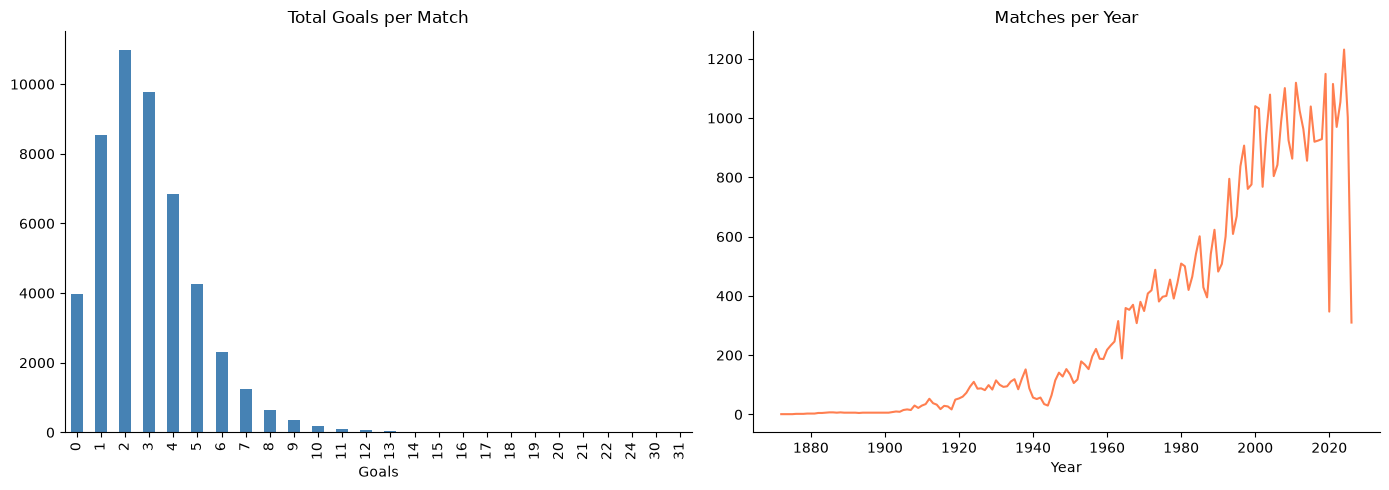


Result distribution:
result
H    49.0%
A    28.3%
D    22.7%
Name: proportion, dtype: str


In [11]:
if matches is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Goals per match distribution
    matches['total_goals'].value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
    axes[0].set_title('Total Goals per Match')
    axes[0].set_xlabel('Goals')

    # Matches per year
    matches.groupby(matches['date'].dt.year).size().plot(ax=axes[1], color='coral')
    axes[1].set_title('Matches per Year')
    axes[1].set_xlabel('Year')

    plt.tight_layout()
    plt.show()

    # Result distribution
    print('\nResult distribution:')
    print(matches['result'].value_counts(normalize=True).map('{:.1%}'.format))

## 3. Elo Ratings

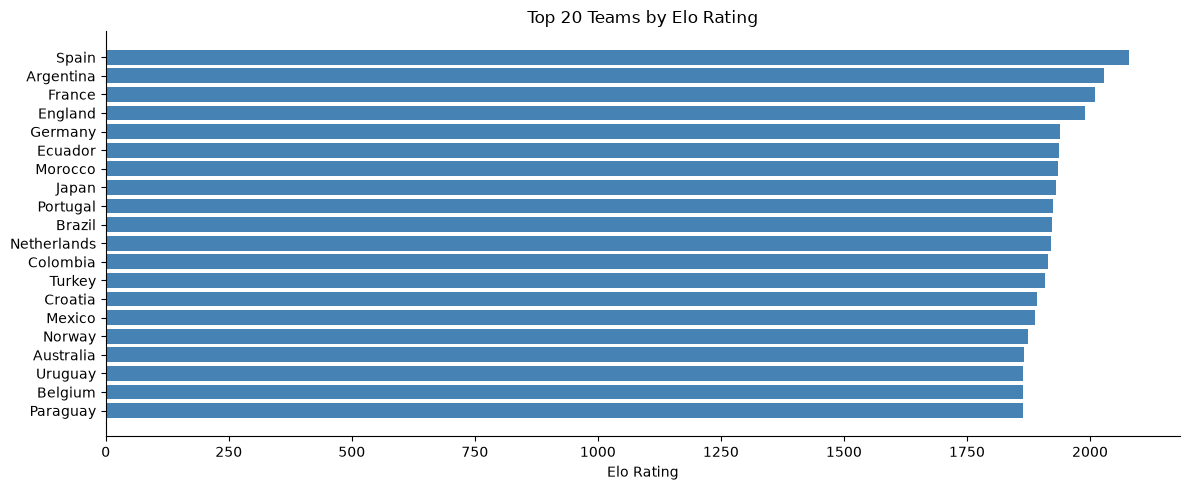

In [12]:
if matches is not None:
    from src.features.elo import EloRatingSystem

    elo = EloRatingSystem(k_base=30)
    elo_history = elo.fit(matches)
    elo.sanity_check()

    # Top 20 current ratings
    top20 = sorted(elo.ratings.items(), key=lambda x: -x[1])[:20]
    teams, ratings = zip(*top20)

    plt.figure(figsize=(12, 5))
    bars = plt.barh(range(len(teams)), ratings, color='steelblue')
    plt.yticks(range(len(teams)), teams)
    plt.gca().invert_yaxis()
    plt.xlabel('Elo Rating')
    plt.title('Top 20 Teams by Elo Rating')
    plt.tight_layout()
    plt.show()

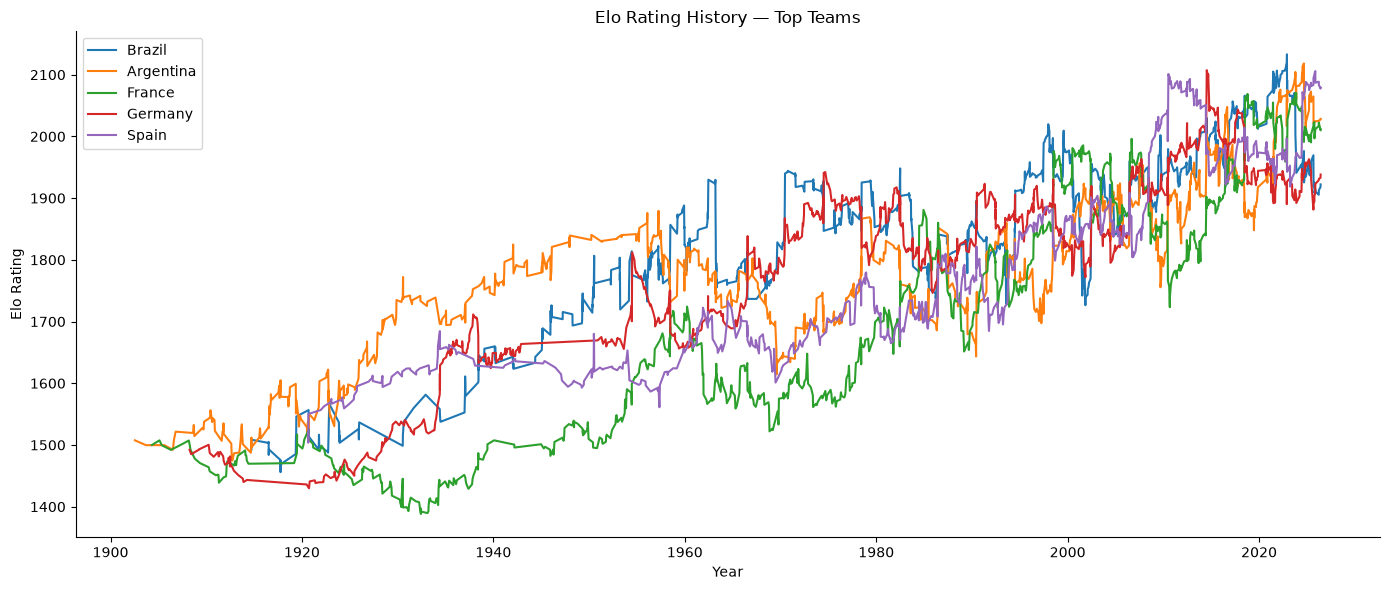

In [13]:
if matches is not None:
    # Plot Elo history for select teams
    TEAMS = ['Brazil', 'Argentina', 'France', 'Germany', 'Spain']

    plt.figure(figsize=(14, 6))
    for team in TEAMS:
        th = elo_history[elo_history['team'] == team].sort_values('date')
        plt.plot(th['date'], th['elo_after'], label=team)

    plt.title('Elo Rating History — Top Teams')
    plt.xlabel('Year')
    plt.ylabel('Elo Rating')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Dixon-Coles Model

In [ ]:
if matches is not None:
    from src.models.dixon_coles import DixonColesModel

    # Fit on data up to end of 2023 as a trial
    train = matches[matches['date'] < '2024-01-01']
    dc = DixonColesModel(half_life_days=365)
    dc.fit(train)
    print('Dixon-Coles fitted!')
    print(f"  home_advantage = {dc.params_['home_advantage']:.3f}")
    print(f"  rho            = {dc.params_['rho']:.3f}")

In [ ]:
if matches is not None:
    # Sample prediction
    pred = dc.predict('France', 'Argentina', neutral_venue=True)
    print('France vs Argentina (neutral):')
    print(f"  Home win (France): {pred['home_win']:.1%}")
    print(f"  Draw:              {pred['draw']:.1%}")
    print(f"  Away win (Arg):    {pred['away_win']:.1%}")
    print(f"  Over 2.5:          {pred['over_2_5']:.1%}")
    print(f"  BTTS:              {pred['btts']:.1%}")
    print()
    print('Top scorelines:')
    for h, a, p in dc.top_scorelines(pred):
        print(f"  {h}-{a}: {p:.2%}")

In [ ]:
if matches is not None:
    # Visualise scoreline probability matrix
    import matplotlib.colors as mcolors
    matrix = pred['score_matrix'][:6, :6]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix, cmap='Blues')
    plt.colorbar(im, ax=ax, label='Probability')
    ax.set_xlabel('Argentina goals')
    ax.set_ylabel('France goals')
    ax.set_title('France vs Argentina — Scoreline Probabilities')
    for i in range(6):
        for j in range(6):
            ax.text(j, i, f'{matrix[i,j]:.2%}', ha='center', va='center',
                    color='black' if matrix[i,j] < 0.06 else 'white', fontsize=9)
    plt.tight_layout()
    plt.show()

## 5. Set-Piece Attribution (indicative)

In [ ]:
from src.models.setpiece_attribution import SetPieceAttribution

sp = SetPieceAttribution()

if matches is not None:
    total_xg = pred['expected_home_goals'] + pred['expected_away_goals']
    sp_result = sp.predict(total_xg, home_team='France', away_team='Argentina')
    print('Set-piece attribution (France vs Argentina):')
    for k, v in sp_result.items():
        if k != 'uncertainty_note':
            print(f'  {k}: {v}')
    print()
    print(sp_result['uncertainty_note'])